In [36]:
import librosa
import numpy as np

path = "data/misirlou.mp3"
y, sr = librosa.load(path, sr=22050)
y = y/np.max(np.abs(y)) 

In [37]:
S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512, center=False))
S_db = librosa.amplitude_to_db(S, ref=np.max)
S_db

array([[-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       ...,
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.],
       [-80., -80., -80., ..., -80., -80., -80.]],
      shape=(1025, 5866), dtype=float32)

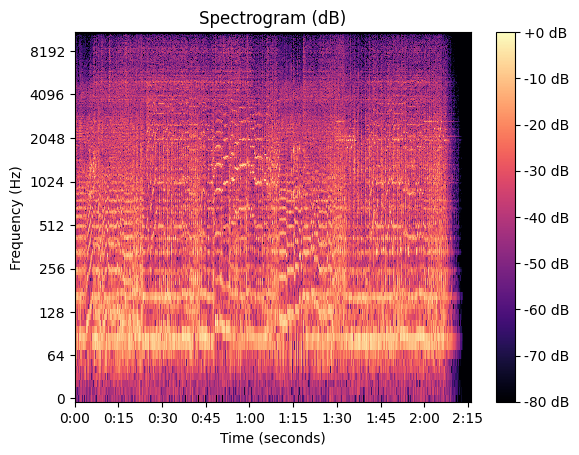

In [38]:
import matplotlib.pyplot as plt

librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='log'
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (dB)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.show()

In [39]:
print(S_db.max())  
print(S_db.min())

0.0
-80.0


In [40]:
num_bins = S_db.shape[0]

bands =  {
    "low": S_db[0:int(num_bins * 0.1), :],
    "mid": S_db[int(num_bins * 0.1):int(num_bins * 0.5), :],
    "high": S_db[int(num_bins * 0.5):, :]
}
bands

{'low': array([[-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        ...,
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.]],
       shape=(102, 5866), dtype=float32),
 'mid': array([[-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        ...,
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.]],
       shape=(410, 5866), dtype=float32),
 'high': array([[-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80., -80., -80.],
        ...,
        [-80., -80., -80., ..., -80., -80., -80.],
        [-80., -80., -80., ..., -80.,

In [41]:
from scipy.ndimage import maximum_filter

percentile = 80
neighborhood_size = 20

local_max = maximum_filter(S_db, size=neighborhood_size) == S_db
thresholds = np.percentile(S_db, percentile, axis=0)

frame_energy = np.mean(S_db, axis=0)
active_frames = frame_energy >= np.percentile(frame_energy, 20)
adaptive_floor = np.percentile(S_db, 10)
abs_floor_db = max(adaptive_floor, -60)

detected = (
    local_max
    & (S_db >= thresholds[np.newaxis, :])
    & (S_db >= abs_floor_db)
    & active_frames[np.newaxis, :]
    )

peaks = np.argwhere(detected)
peaks

array([[   7, 1005],
       [   7, 4790],
       [   7, 4969],
       ...,
       [ 904, 1328],
       [ 904, 2312],
       [ 904, 3729]], shape=(5980, 2))

In [42]:
peaks_all = []

start = 0
for band_name in ["low", "mid", "high"]:
    band = bands[band_name]
    for f, t in peaks:
        peaks_all.append((f + start, t))

    start += band.shape[0]

peaks_all = np.array(peaks_all)
peaks_all

array([[   7, 1005],
       [   7, 4790],
       [   7, 4969],
       ...,
       [1416, 1328],
       [1416, 2312],
       [1416, 3729]], shape=(17940, 2))

In [43]:
from collections import defaultdict

max_per_time = 4
buckets = defaultdict(list)

for f, t in peaks:
    buckets[t].append((f, t, S_db[f, t]))

final_peaks = []
for t in buckets:
    selected = sorted(buckets[t], key=lambda x: -x[2])[:max_per_time]
    final_peaks.extend((f, t) for f, t, _ in selected)

final_peaks = np.array(final_peaks, dtype=np.int32)

len(final_peaks)

5711

In [ ]:
from utils import pack_hash, generate_hashes_from_peaks

In [ ]:
hashes = generate_hashes_from_peaks(
    final_peaks,
    dt_min=5,
    dt_max=50,
    fan_value=10,
)
hashes

Generating hashes: 100%|██████████| 5711/5711 [00:00<00:00, 239807.68it/s]


array([[ 277184517,          9],
       [ 277377029,          9],
       [ 277532677,          9],
       ...,
       [1564880925,       5484],
       [1564815389,       5484],
       [1565089821,       5484]], shape=(56806, 2))

Total hashes: 56806
Time range: 0.2089795918367347 to 127.33823129251701
Unique hashes: 55290


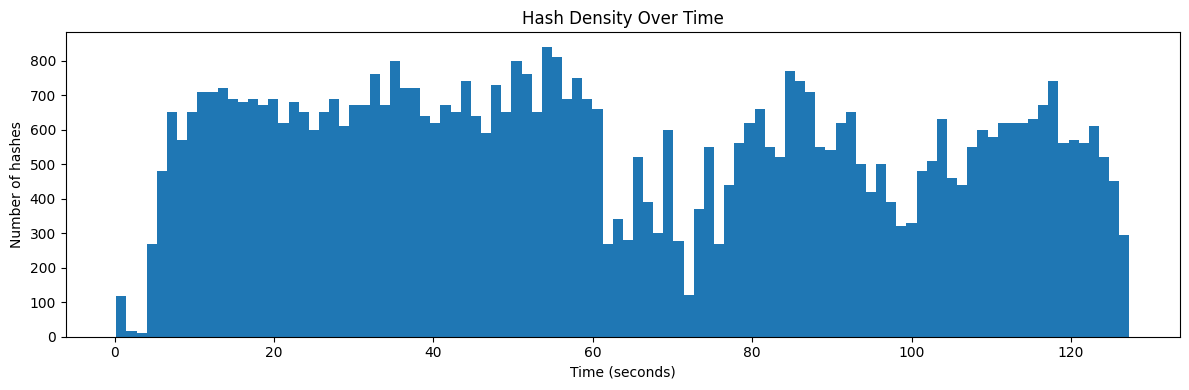

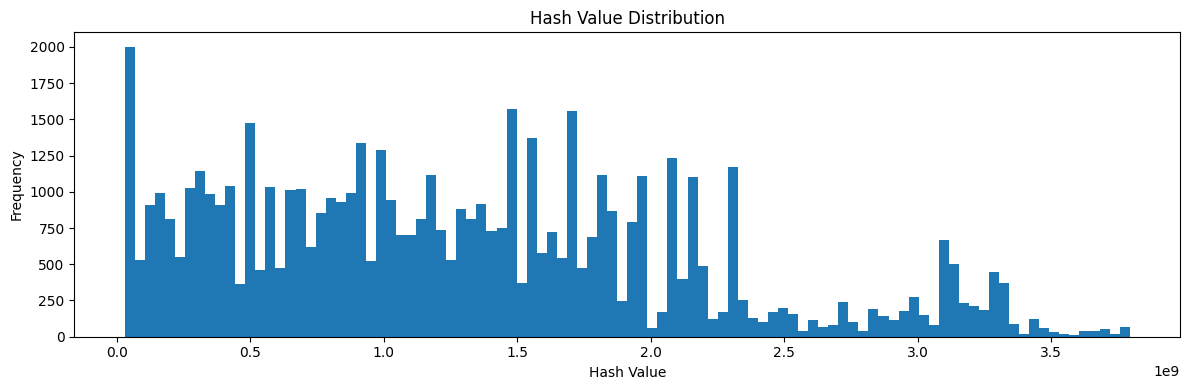

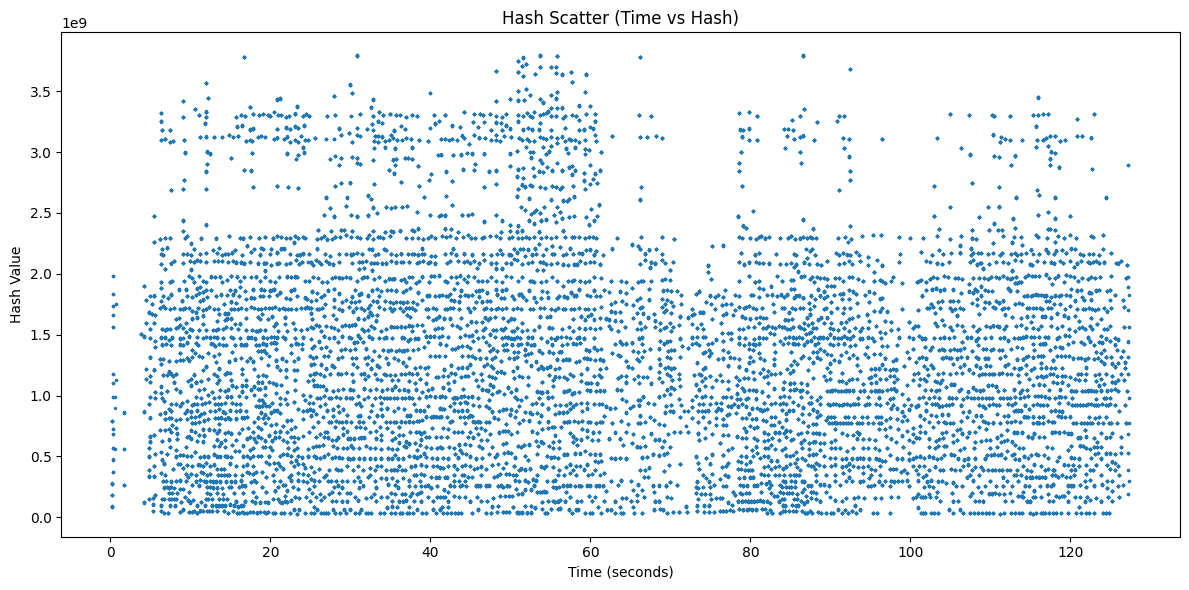

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import librosa


hashes = np.array(hashes)

sr = 22050
hop_length = 512

hash_values = hashes[:, 0]
time_frames = hashes[:, 1]

times = librosa.frames_to_time(time_frames, sr=sr, hop_length=hop_length)

print("Total hashes:", len(hashes))
print("Time range:", times.min(), "to", times.max())
print("Unique hashes:", len(np.unique(hash_values)))


plt.figure(figsize=(12, 4))
plt.hist(times, bins=100)
plt.title("Hash Density Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of hashes")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 4))
plt.hist(hash_values, bins=100)
plt.title("Hash Value Distribution")
plt.xlabel("Hash Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

MAX_POINTS = 50000

if len(times) > MAX_POINTS:
    idx = np.random.choice(len(times), MAX_POINTS, replace=False)
    times_plot = times[idx]
    hash_plot = hash_values[idx]
else:
    times_plot = times
    hash_plot = hash_values

plt.figure(figsize=(12, 6))
plt.scatter(times_plot, hash_plot, s=2)
plt.title("Hash Scatter (Time vs Hash)")
plt.xlabel("Time (seconds)")
plt.ylabel("Hash Value")
plt.tight_layout()
plt.show()